# 02 - BB84 con attacco intercept-resend


Simulazione di BB84 in presenza di un attacco intercept-resend.

Eve intercetta i qubit con probabilità variabile. Quando intercetta, misura in una base casuale e reinvia a Bob un nuovo qubit coerente con il risultato ottenuto.

L'effetto dell'attacco viene misurato tramite il QBER sulla chiave sifted. In caso di intercettazione completa, il QBER atteso è circa il 25%. Una soglia didattica di riferimento è QBER circa 0.11.

## Setup

Import dei moduli del progetto e cartelle per tabelle e figure.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

current_path = Path.cwd()

if (current_path / "src" / "bb84.py").exists():
    project_root = current_path
else:
    project_root = current_path.parent

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from bb84 import run_bb84_protocol_with_eve
from qkd_core import sift_keys, compute_qber
from metrics import (
    QBER_THRESHOLD_BB84,
    compute_sifted_key_length,
    compute_sifted_key_rate,
    decide_qber_acceptance,
)

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("Setup completato.")

Setup completato.


## Parametri

Impostiamo il numero di round, il seed, le probabilità di intercettazione e la soglia QBER.

In [2]:
N_ROUNDS = 1000
SEED = 42
INTERCEPT_PROBABILITIES = [0.0, 0.25, 0.5, 0.75, 1.0]
QBER_THRESHOLD = QBER_THRESHOLD_BB84

print("Numero di round:", N_ROUNDS)
print("Seed:", SEED)
print("Probabilità di intercettazione:", INTERCEPT_PROBABILITIES)
print("Soglia QBER:", QBER_THRESHOLD)

Numero di round: 1000
Seed: 42
Probabilità di intercettazione: [0.0, 0.25, 0.5, 0.75, 1.0]
Soglia QBER: 0.11


## Esperimento singolo con Eve sempre attiva

BB84 con Eve attiva in ogni round, seguito da sifting e calcolo del QBER.

In [3]:
results_eve = run_bb84_protocol_with_eve(
    N_ROUNDS,
    intercept_probability=1.0,
    seed=SEED,
)

alice_key, bob_key = sift_keys(results_eve)
qber = compute_qber(alice_key, bob_key)

df = pd.DataFrame(results_eve)

rounds_path = tables_dir / "bb84_eve_rounds.csv"
df.to_csv(rounds_path, index=False)

print("Lunghezza chiave Alice dopo sifting:", len(alice_key))
print("Lunghezza chiave Bob dopo sifting:", len(bob_key))
print("QBER:", qber)
print(f"Tabella dei round salvata in: {rounds_path}")
df.head(10)

Lunghezza chiave Alice dopo sifting: 509
Lunghezza chiave Bob dopo sifting: 509
QBER: 0.22986247544204322
Tabella dei round salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_eve_rounds.csv


,round,alice_bit,alice_basis,bob_basis,bob_bit,keep,eve_intercepted,eve_basis,eve_bit
0,1,0,X,X,0,True,True,X,0
1,2,1,X,Z,1,False,True,X,1
2,3,1,Z,X,0,False,True,Z,1
3,4,0,Z,Z,1,True,True,X,0
4,5,0,X,X,0,True,True,Z,1
5,6,1,Z,Z,1,True,True,Z,1
6,7,0,Z,Z,0,True,True,X,0
7,8,1,X,X,1,True,True,X,1
8,9,0,Z,X,0,False,True,Z,0
9,10,0,X,Z,1,False,True,Z,1


## Sintesi esperimento singolo

Metriche principali dell'esperimento con Eve sempre attiva.

In [4]:
sifted_key_length = compute_sifted_key_length(alice_key)
sifted_key_rate = compute_sifted_key_rate(alice_key, N_ROUNDS)
accepted = decide_qber_acceptance(qber, QBER_THRESHOLD)

summary = {
    "protocol": "BB84 intercept-resend",
    "n_rounds": N_ROUNDS,
    "intercept_probability": 1.0,
    "sifted_key_length": sifted_key_length,
    "sifted_key_rate": sifted_key_rate,
    "qber": qber,
    "qber_threshold": QBER_THRESHOLD,
    "accepted": accepted,
    "seed": SEED,
}

summary_df = pd.DataFrame([summary])

summary_path = tables_dir / "bb84_eve_summary.csv"
summary_df.to_csv(summary_path, index=False)

print(f"Sintesi salvata in: {summary_path}")
summary_df

Sintesi salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_eve_summary.csv


,protocol,n_rounds,intercept_probability,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,seed
0,BB84 intercept-resend,1000,1.0,509,0.509,0.229862,0.11,False,42


## Sweep sulla probabilità di intercettazione

Sweep su diversi valori di `intercept_probability` con tabella comparativa.

In [5]:
sweep_results = []

for i in range(len(INTERCEPT_PROBABILITIES)):
    probability = INTERCEPT_PROBABILITIES[i]

    results = run_bb84_protocol_with_eve(
        N_ROUNDS,
        intercept_probability=probability,
        seed=SEED,
    )

    sweep_alice_key, sweep_bob_key = sift_keys(results)
    sweep_qber = compute_qber(sweep_alice_key, sweep_bob_key)
    sweep_sifted_key_length = compute_sifted_key_length(sweep_alice_key)
    sweep_sifted_key_rate = compute_sifted_key_rate(sweep_alice_key, N_ROUNDS)
    sweep_accepted = decide_qber_acceptance(sweep_qber, QBER_THRESHOLD)

    row = {
        "protocol": "BB84 intercept-resend",
        "n_rounds": N_ROUNDS,
        "intercept_probability": probability,
        "sifted_key_length": sweep_sifted_key_length,
        "sifted_key_rate": sweep_sifted_key_rate,
        "qber": sweep_qber,
        "qber_threshold": QBER_THRESHOLD,
        "accepted": sweep_accepted,
        "seed": SEED,
    }
    sweep_results.append(row)

    print("Probabilità:", probability)
    print("  lunghezza chiave sifted:", sweep_sifted_key_length)
    print("  sifted key rate:", sweep_sifted_key_rate)
    print("  QBER:", sweep_qber)
    print("  chiave accettata:", sweep_accepted)

sweep_df = pd.DataFrame(sweep_results)

sweep_path = tables_dir / "bb84_eve_qber_vs_interception.csv"
sweep_df.to_csv(sweep_path, index=False)

print(f"Tabella sweep salvata in: {sweep_path}")
sweep_df

Probabilità: 0.0
  lunghezza chiave sifted: 509
  sifted key rate: 0.509
  QBER: 0.0
  chiave accettata: True
Probabilità: 0.25
  lunghezza chiave sifted: 509
  sifted key rate: 0.509
  QBER: 0.05697445972495088
  chiave accettata: True
Probabilità: 0.5
  lunghezza chiave sifted: 509
  sifted key rate: 0.509
  QBER: 0.10805500982318271
  chiave accettata: True
Probabilità: 0.75
  lunghezza chiave sifted: 509
  sifted key rate: 0.509
  QBER: 0.17681728880157171
  chiave accettata: False
Probabilità: 1.0
  lunghezza chiave sifted: 509
  sifted key rate: 0.509
  QBER: 0.25343811394891946
  chiave accettata: False
Tabella sweep salvata in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\tables\bb84_eve_qber_vs_interception.csv


,protocol,n_rounds,intercept_probability,sifted_key_length,sifted_key_rate,qber,qber_threshold,accepted,seed
0,BB84 intercept-resend,1000,0.00,509,0.509,0.000000,0.11,True,42
1,BB84 intercept-resend,1000,0.25,509,0.509,0.056974,0.11,True,42
2,BB84 intercept-resend,1000,0.50,509,0.509,0.108055,0.11,True,42
3,BB84 intercept-resend,1000,0.75,509,0.509,0.176817,0.11,False,42
4,BB84 intercept-resend,1000,1.00,509,0.509,0.253438,0.11,False,42


## Grafico QBER vs probabilità di intercettazione

Andamento del QBER al crescere della probabilità di intercettazione di Eve.

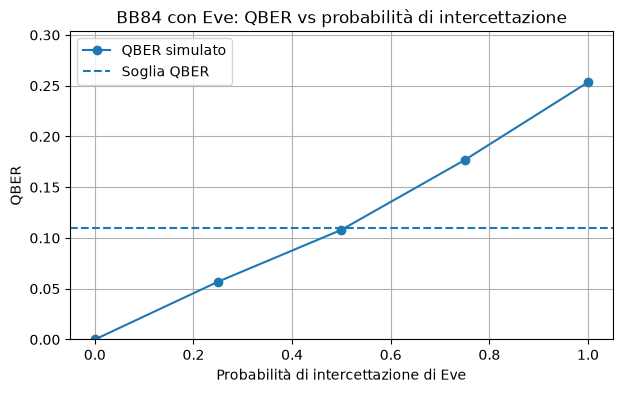

Grafico QBER salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_eve_qber_vs_interception.png


In [6]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["intercept_probability"],
    sweep_df["qber"],
    marker="o",
    label="QBER simulato",
)
plt.axhline(
    QBER_THRESHOLD,
    linestyle="--",
    label="Soglia QBER",
)
plt.xlabel("Probabilità di intercettazione di Eve")
plt.ylabel("QBER")
plt.title("BB84 con Eve: QBER vs probabilità di intercettazione")
plt.grid(True)
plt.legend()
plt.ylim(0, max(0.3, sweep_df["qber"].max() + 0.05))

qber_figure_path = figures_dir / "bb84_eve_qber_vs_interception.png"
plt.savefig(qber_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico QBER salvato in: {qber_figure_path}")

## Grafico sifted key rate vs probabilità di intercettazione

Il sifted key rate misura la frazione di round mantenuti dopo il confronto delle basi.

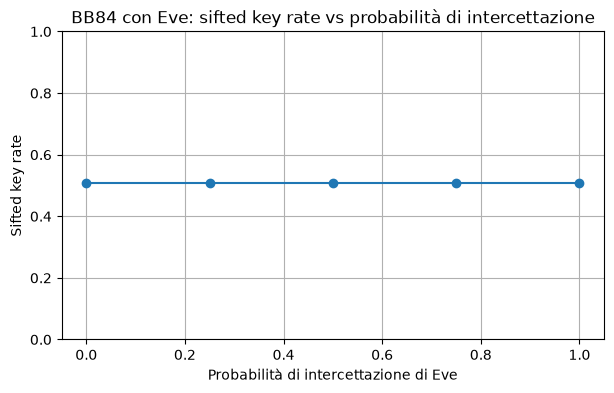

Grafico sifted key rate salvato in: c:\Users\daniz\Desktop\dani uni\Magistrale\Secondo anno\Quantum Computing\Progetto\qkd-cybersecurity-project\results\figures\bb84_eve_sifted_key_rate_vs_interception.png


In [7]:
plt.figure(figsize=(7, 4))
plt.plot(
    sweep_df["intercept_probability"],
    sweep_df["sifted_key_rate"],
    marker="o",
)
plt.xlabel("Probabilità di intercettazione di Eve")
plt.ylabel("Sifted key rate")
plt.title("BB84 con Eve: sifted key rate vs probabilità di intercettazione")
plt.grid(True)
plt.ylim(0, 1)

rate_figure_path = figures_dir / "bb84_eve_sifted_key_rate_vs_interception.png"
plt.savefig(rate_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Grafico sifted key rate salvato in: {rate_figure_path}")

## Commento finale

Senza Eve il QBER resta nullo o vicino a zero nel modello ideale. Aumentando `intercept_probability`, il QBER cresce perché Eve introduce errori quando misura nella base sbagliata.

Con intercettazione completa, il valore simulato tende al comportamento atteso di circa 25%. Il sifted key rate resta invece circa 0.5, perché dipende soprattutto dalla scelta casuale delle basi di Alice e Bob.

I risultati preparano il confronto con E91 e con i canali rumorosi.